<a href="https://colab.research.google.com/github/AngeNana23/Assignment-11/blob/main/Assignment11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC

In [7]:
IMG_SIZE = 32

data = []
labels = []
class_names = []

dataset_path = "/content/drive/MyDrive/images"

categories = sorted(os.listdir(dataset_path))

for label, category in enumerate(categories):
    class_names.append(category)
    folder_path = os.path.join(dataset_path, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append(img.flatten())
            labels.append(label)
        except:
            continue

X = np.array(data) / 255.0
y = np.array(labels)

print("Classes:", class_names)
print("Dataset shape:", X.shape)

Classes: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']
Dataset shape: (309, 3072)


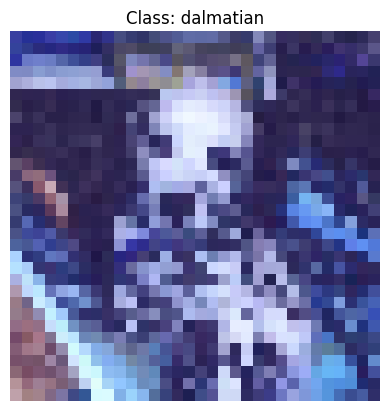

In [8]:
plt.imshow(X[0].reshape(32,32,3))
plt.title(f"Class: {class_names[y[0]]}")
plt.axis('off')
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [13]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.7258064516129032

Classification Report:
               precision    recall  f1-score   support

   dalmatian       0.75      0.64      0.69        14
 dollar_bill       1.00      0.70      0.82        10
       pizza       0.55      0.60      0.57        10
 soccer_ball       0.64      0.82      0.72        11
   sunflower       0.78      0.82      0.80        17

    accuracy                           0.73        62
   macro avg       0.74      0.72      0.72        62
weighted avg       0.75      0.73      0.73        62



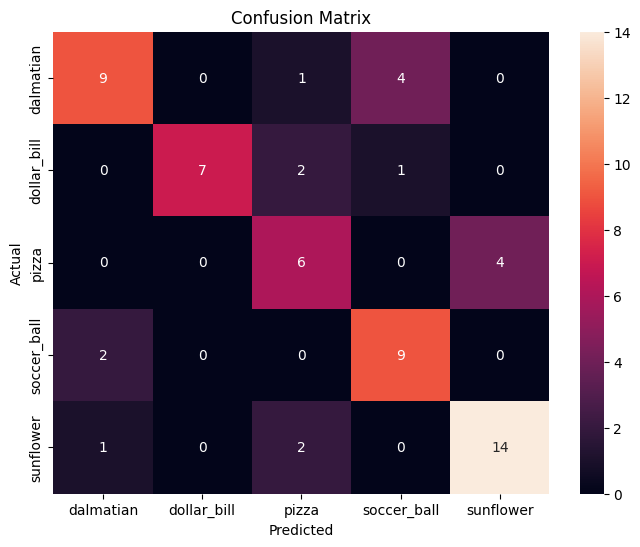

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

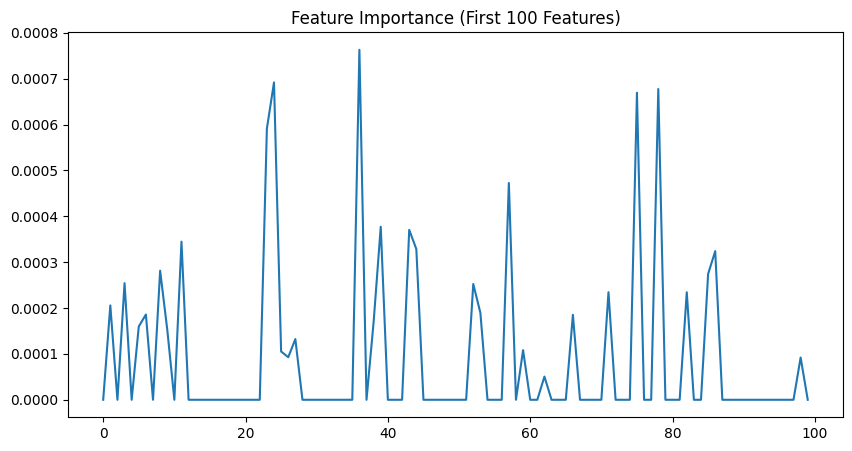

In [15]:
importances = best_model.feature_importances_

plt.figure(figsize=(10,5))
plt.plot(importances[:100])
plt.title("Feature Importance (First 100 Features)")
plt.show()

In [17]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.flatten() / 255.0
    img = img.reshape(1, -1)

    pred = best_model.predict(img)[0]
    return class_names[pred]

In [19]:
test_path = "/content/drive/MyDrive/images/soccer_ball/image_0064.jpg"
print("Prediction:", predict_image(test_path))

Prediction: soccer_ball


In [22]:
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7903225806451613
